Se está haciendo un estudio de propiedaddes en la octava regón del país y a usted le han encargado analizar un set de datos provisto por el ministerio de vivienda y urbanismo. El dataset, tiene información respecto a los precios de las propiedades y la caracterización de los siguientes atributos:
- __CRIM__: Tasa de criminalidad per cápita del sector
- __ZN__: Proporción de suelo residencial para lotes sobre 25.000 sq ft
- __INDUS__: Proporción de negocios no-retail por sector
- __CHAS__: 1 si el tramo limita con el Río Biobío, caso contario, 0
- __NOX__: Concentracion óxido nítrico (part per 10 million)
- __RM__: Promedio número de dormitorios por vivienda
- __AGE__: Proporción de viviendas ocupadas por sus propietarios construidas previo a 1940
- __DIS__: Distancias ponderadas a cinco centros de empleo de Boston
- __RAD__: Índice de accesibilidad a carreteras radiales
- __TAX__: Tasa de impuestos a la propiedad de valor total por $10.000
- __PTRATIO__: Proporción alumno-profesor por ciuddad
- __B__: 1000(Bk - 0,63)², donde Bk es la proporción de personas de otras etnias por sector
- __LSTAT__: Porcentaje de menor estatus de la población
- __MEDV__: Valor de las viviendas en 1000 US

Se le solicita que, en su análisis de datos, incorpore como mínimo lo siguiente:
1. Identifique los tipos de variable de cada atributo del set de datos
2. Defina medidas de tendencia central y de disperción que utilizará en el estudio. ¿Qué pasa con la variable CHAS?
3. Realice un análisis exploratorio y visual. ¿Qué insights puede encontrar en la información?
4. Realice un modelamiento regresivo. ¿Qué nivel de ajuste tiene el modelo?¿Cuáles son las variables que más inciden en el precio de una propiedad?

# 0. Librerias y carga de dataset

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.tools.eval_measures as metrics

In [3]:
df = pd.read_csv('precios-propiedades.csv')

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


# 1. Tipos de variables

In [5]:
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

# 2. Medidas de tendencia central y de disperción

In [6]:
# Verificar valores nulos
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [7]:
# Definir las medidas
medidas = {
    "Media": df.mean(),
    "Mediana": df.median(),
    "Moda": df.mode().iloc[0],
    "Varianza": df.var(),
    "Desviación estándar": df.std(),
    "Rango": df.max() - df.min(),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
}

resumen = pd.DataFrame(medidas)
resumen

,Media,Mediana,Moda,Varianza,Desviación estándar,Rango,IQR
CRIM,3.613524,0.25651,0.01501,73.986578,8.601545,88.96988,3.595038
ZN,11.363636,0.00000,0.00000,543.936814,23.322453,100.00000,12.500000
INDUS,11.136779,9.69000,18.10000,47.064442,6.860353,27.28000,12.910000
CHAS,0.069170,0.00000,0.00000,0.064513,0.253994,1.00000,0.000000
NOX,0.554695,0.53800,0.53800,0.013428,0.115878,0.48600,0.175000
RM,6.284634,6.20850,5.71300,0.493671,0.702617,5.21900,0.738000
AGE,68.574901,77.50000,100.00000,792.358399,28.148861,97.10000,49.050000
DIS,3.795043,3.20745,3.49520,4.434015,2.105710,10.99690,3.088250
RAD,9.549407,5.00000,24.00000,75.816366,8.707259,23.00000,20.000000
TAX,408.237154,330.00000,666.00000,28404.759488,168.537116,524.00000,387.000000


In [8]:
df['CHAS'].value_counts()

CHAS
0.0    471
1.0     35
Name: count, dtype: int64

La variable __CHAS__ es binaria y solo el 6,9% de las viviendas colinda con el Río Biobío, por lo que mediana y la moda son 0.

# 3. Análisis exploratorio y visual

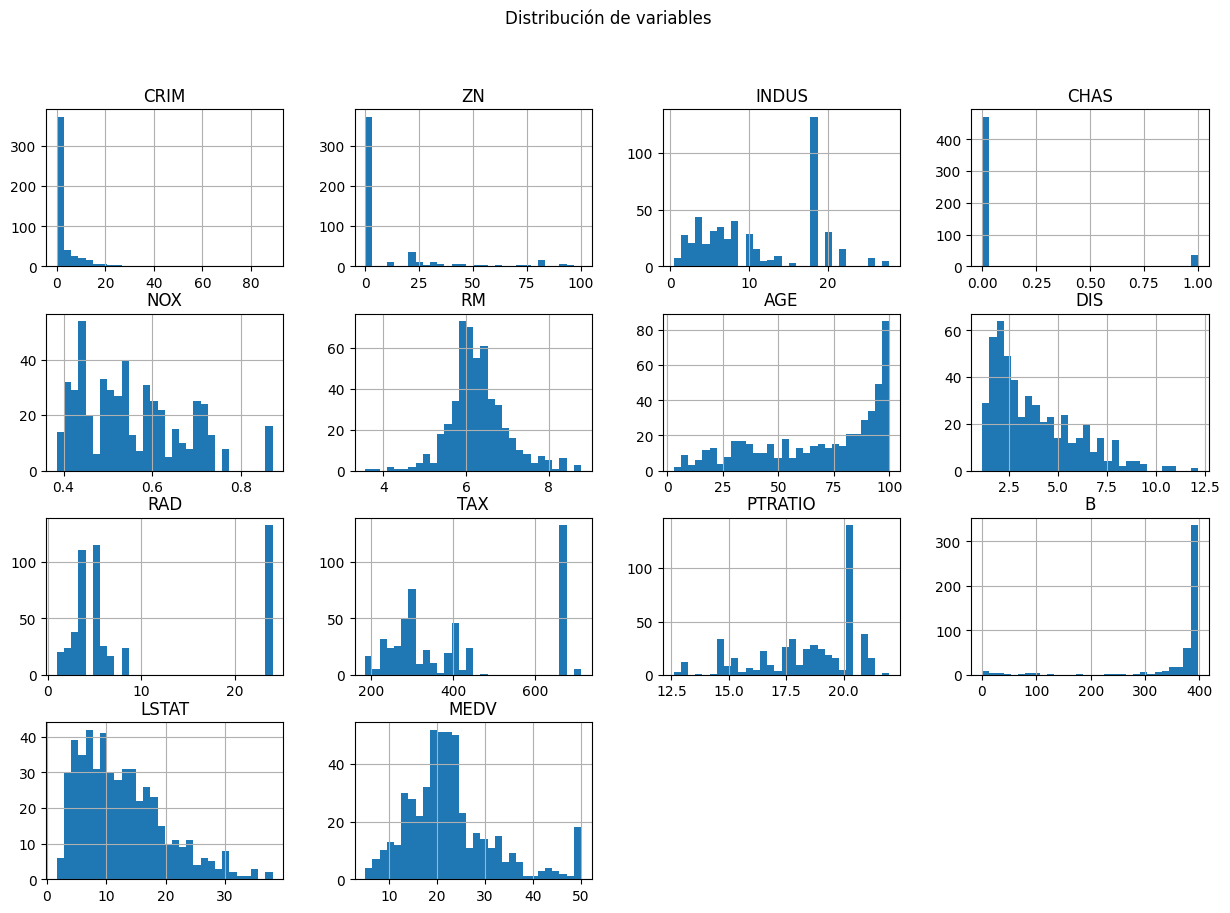

In [9]:
df.hist(bins=30, figsize=(15,10))
plt.suptitle("Distribución de variables")
plt.show()

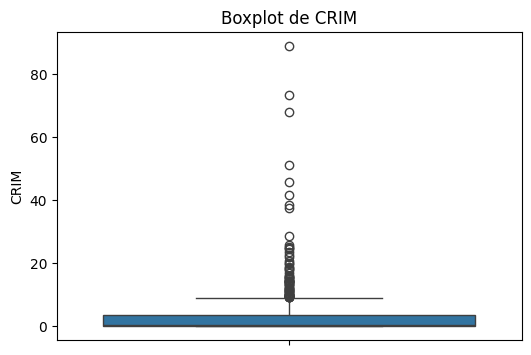

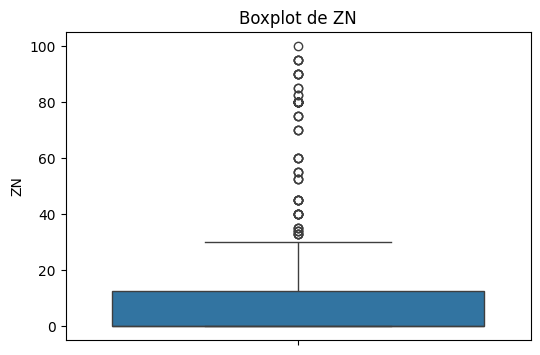

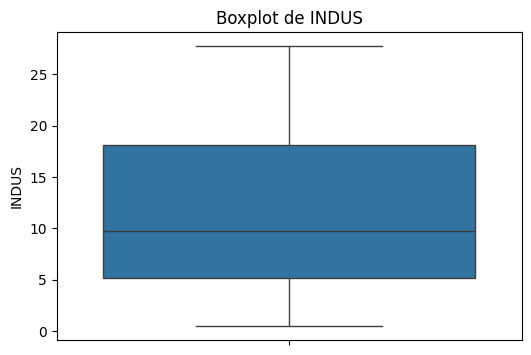

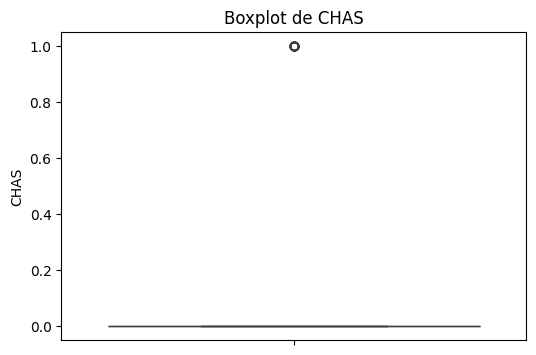

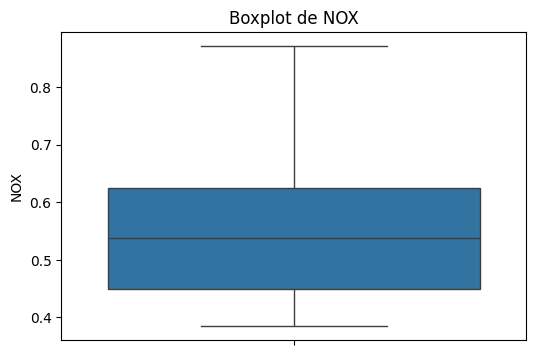

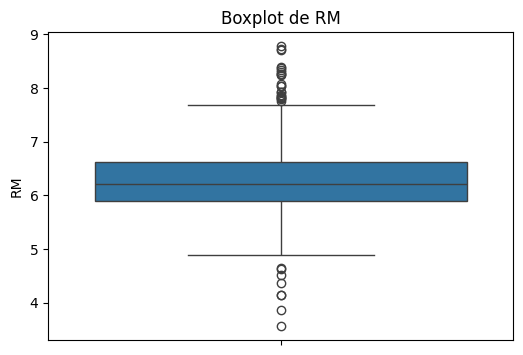

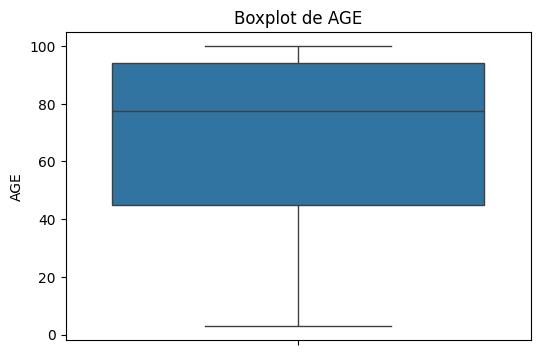

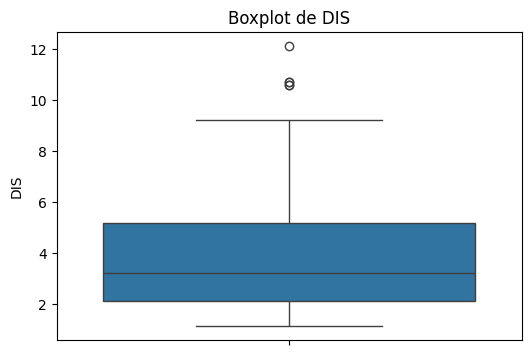

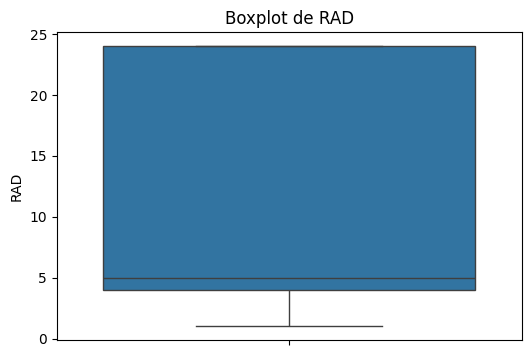

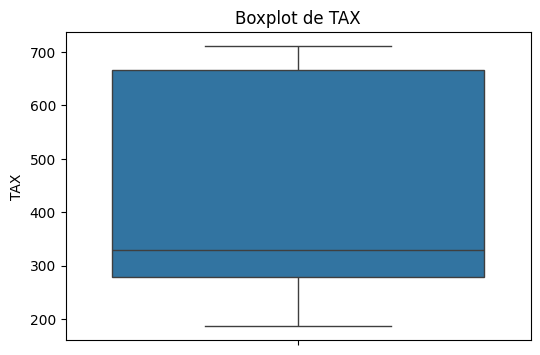

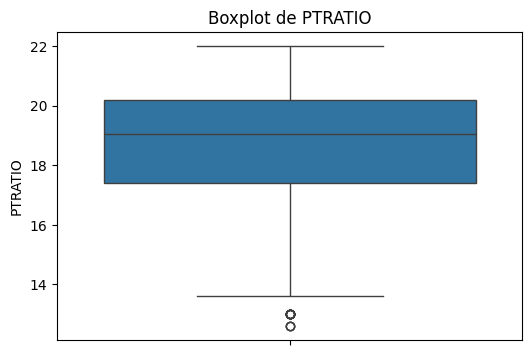

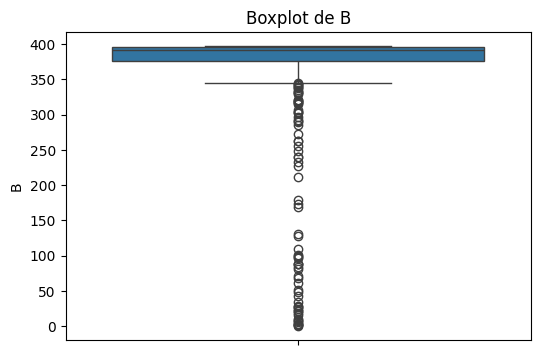

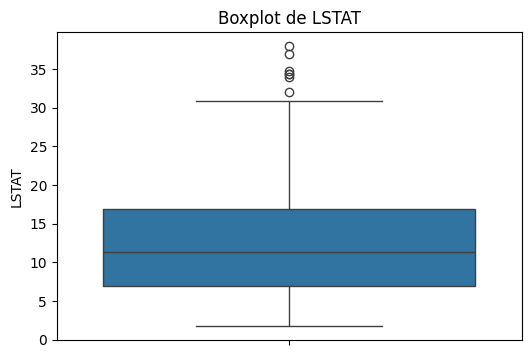

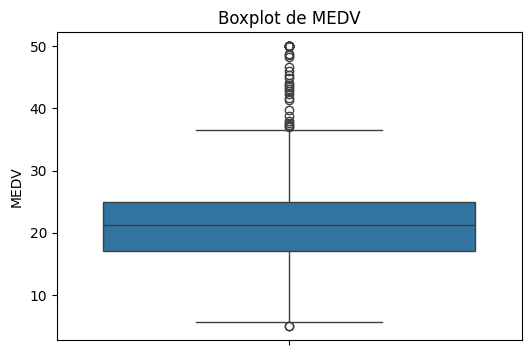

In [10]:
# Boxplots individuales
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

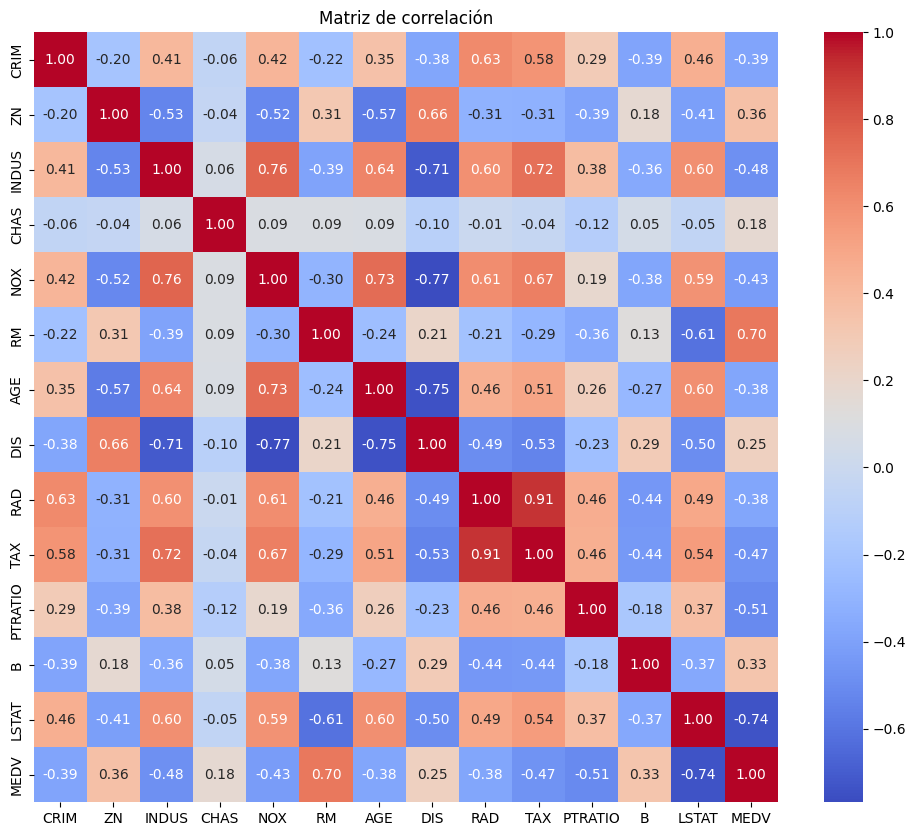

In [11]:
# Matriz de correlación
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## Insights
### Distribución de variables
- La tasa de criminalidad per cápita del sector (__CRIM__), la proporción de suelo residencial para lotes sobre 25.000 sq ft (__ZN__), el porcentaje de menor estatus de la población (__LSTAT__) y la distancia ponderada a cinco centros de empleo (__DIS__) tienen distribuciones sesgadas.
### Boxplots
- La tasa de criminalidad per cápita del sector (__CRIM__), la tasa de criminalidad per cápita del sector (__CRIM__) y la proporción de suelo residencial para lotes sobre 25.000 sq ft (__ZN__) tienen gran cantidad de outliers en valores altos
- La proporción de viviendas ocupadas por sus dueños construidas previo a 1940 (__AGE__) muestra valores altos
- El índice de accesibilidad a carreteras radiales (__RAD__) y la tasa de impuestos a la propiedad de vvalor total por $10,000 (__TAX__) muestran saltos discretos
- El valor de las viviendas en 100 US (__MEDV__) tiene outliers en precios altos con un limite superior en 50
### Correlaciones
- El promedio de número de dormitorios por vivienda (__RM__) y el valor de las viviendas en 100 US (__MEDV__) tienen una correlación positiva (~0.7), lo que indica que más habitaciones tenga, mayor es el valor de la vivienda
- El porcentaje de menor estatus de la población (__LSTAT__) y el valor de las viviendas en 100 US (__MEDV__) tienen una correlación negativa de ~-0.74, a mayor porcentaje de la población de estatus bajo, menor es el valor de la vivienda
- La proporción de alumno-profesor por ciudad (__PTRATIO__) y el valor de las viviendas en 100 US (__MEDV__) tiene una correlacion negativa (~-0.5), entre más alumnos por porfesor, menor es el valor de la vivienda
- El índice de accesibilidad a carreteras radiales (__RAD__) y la tasa de impuestos a la propiedad de valor total por $10,000 (__TAX__) tienen una correlación alta entre sí (~9.1), reflejando relación entre impuestos y accesibilidad vial.
### Outliers
- La tasa de criminalidad per cápita del sector (__CRIM__), la proporción de suelo residencial para lotes sobre 25.000 sq ft (__ZN__), el porcentaje de menor estatus de la población (__LSTAT__) y el valor de las viviendas en 100 US (__MEDV__) tienen muchos valores extremos

# 4. Modelamiento regresivo

In [15]:
lm = smf.ols(formula='Q("MEDV") ~ Q("RM") + Q("LSTAT") + Q("PTRATIO") + Q("NOX") + Q("CHAS")', data=df).fit()

In [16]:
lm.params

Intercept       19.436092
Q("RM")          4.479138
Q("LSTAT")      -0.535127
Q("PTRATIO")    -0.889719
Q("NOX")        -3.810469
Q("CHAS")        3.641157
dtype: float64

In [17]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Q("MEDV")   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     221.5
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          2.82e-124
Time:                        13:54:39   Log-Likelihood:                -1544.8
No. Observations:                 506   AIC:                             3102.
Df Residuals:                     500   BIC:                             3127.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       19.4361      3.952      4.918      0.000      11.672      27.200
Q("RM")          4.4791      0.422     10.617      0.000       3.650       5.308
Q("LSTAT")      -0.5351      0.049    -10.853      0.000      -0.632      -0.438
Q("PTRATIO")    -0.8897      0.117     -7.633      0.000      -1.119      -0.661
Q("NOX")        -3.8105      2.492     -1.529      0.127      -8.707       1.086
Q("CHAS")        3.6412      0.921      3.953      0.000       1.831       5.451
==============================================================================
Omnibus:                      196.348   Durbin-Watson:                   0.974
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              985.776
Skew:                           1.647   Prob(JB):                    8.74e-215
Kurtosis:                       8.992   Cond. No.                         417.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
y_true = df['MEDV']
y_pred = lm.predict(df[['RM', 'LSTAT', 'PTRATIO', 'NOX', 'CHAS']])
print('MAE: {}'.format(metrics.meanabs(y_true, y_pred)))
print('MSE: {}'.format(metrics.mse(y_true, y_pred)))
print('RMSE: {}'.format(metrics.rmse(y_true, y_pred)))
print('R²: {}'.format(lm.rsquared))
print('R² ajustado: {}'.format(lm.rsquared_adj))

MAE: 3.5829987484919847
MSE: 26.26067012350231
RMSE: 5.12451657461485
R²: 0.6889266975661021
R² ajustado: 0.6858159645417632


Text(0, 0.5, 'Predicción Y')

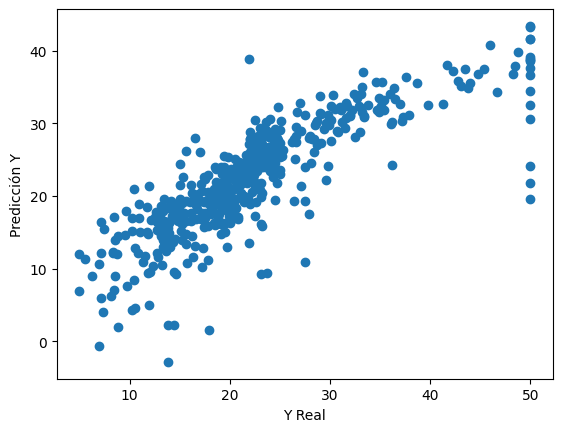

In [21]:
plt.scatter(y_true, y_pred)
plt.xlabel('Y Real')
plt.ylabel('Predicción Y')

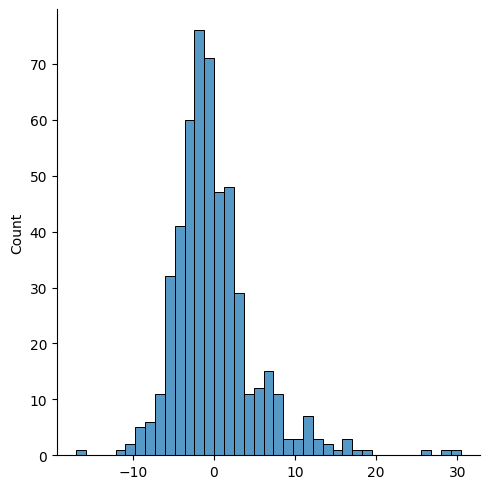

In [22]:
sns.displot(y_true-y_pred)